In [28]:
from spin_sampler import define_hopfield_model , initialize_spins, Sampler
from binary_dimension import compute_histogram, PolynomialDistanceModel , DKL_Optimizer , initial_gauss , select_range 
from configurations import save_fig , create_fig , apply_general_styles , set_font_sizes, make_params_dict
from configurations.plots import FONTSIZES
import matplotlib.pyplot as plt 
import numpy as np

apply_general_styles()

In [56]:

N = 1000
T = 0.6
alpha = 0.04
p = int(alpha * N)
burnin = 100
N_samples = 1000

S0 = initialize_spins(N)
J , patterns = define_hopfield_model(N,p)
print(patterns.shape)
sampler = Sampler(J,T)

S_init = sampler.run_gibbs(S0,burnin,progress=True)
sampler.run_gibbs(S_init,N_samples,store=True,progress=True)

S = sampler.get_chain()
print(S.shape)

r , P = compute_histogram(S)

r_full = np.arange(0,N+1)
Pmin = min(P)
P_new = np.ones_like(r_full)*Pmin*0.1
P_new[r] = P
P_new /= P_new.sum()

r = r_full
P = P_new

(1000, 40)


100%|██████████| 1000/1000 [00:09<00:00, 109.13it/s]


(1000, 1000)


Temperature: 0.6
Degree 1 : KL=-2.5683 in 3 iterations, theta=[0.16962226 1.25934905]
Degree 2 : KL=-0.3212 in 11 iterations, theta=[0.24849488 0.60926304 1.2782201 ]


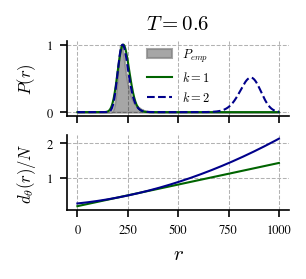

In [69]:
# Setting
set_font_sizes('tight')
eps = 0.00
P0 = 100


degrees = [1,2]
amaxs = [1,1]
colors = ['darkgreen','darkblue']
opts = []
fig , axes = create_fig(2,w=0.55)
r_full = np.arange(0,N+1)
ax = axes[0]
ax.fill_between(r,0,P/max(P),alpha=0.7,color='gray',label=r'$P_{emp}$')
print(f"Temperature: {T}")
for i , (deg,col) in enumerate(zip(degrees,colors)):
    
    dis_model = PolynomialDistanceModel(deg,N)
    rx , Px = select_range(r,P,a_max = amaxs[i]) 
    theta_gauss = initial_gauss(rx,Px)
    theta_gauss[0]/=N  
    theta_aux = theta_gauss #if deg==1 else theta_opt
    theta0 = np.concatenate([theta_gauss,eps*np.ones(deg-1)]) 
    theta_opt , logKL, Nit  = DKL_Optimizer(rx,Px,dis_model).optimize(theta0,max_iter=500,lr=1.)
    print(f'Degree {deg} : KL={logKL:.4f} in {Nit} iterations, theta={theta_opt}')
    opts.append(theta_opt)
    Pmod = dis_model.P_model(r_full,theta_opt)
    ax.plot(r_full,Pmod/max(Pmod),label=fr'$k = {deg}$',c=col,lw=1,ls=['-','--'][i])
ax.legend(frameon=False)
ax.set_ylabel(r'$P(r)$',fontsize=FONTSIZES['s'])
ax.grid(lw=0.5,c='k',ls='--',alpha=0.3)
ax.set_title(rf'$T={T}$')
ax = axes[1]
for deg,col,theta_opt in zip(degrees,colors,opts):
    dis_model = PolynomialDistanceModel(deg,N)
    d_r = dis_model.d(r_full,theta_opt)
    ax.plot(r_full,d_r/N,c=col,lw=1,ls='-')
ax.set_ylabel(r'$d_{\theta}(r)/N$',fontsize=FONTSIZES['s'])
ax.set_xlabel(r'$r$')
ax.grid(lw=0.5,c='k',ls='--',alpha=0.3)

# ax.set_xlim(100,400)
params = make_params_dict(['N','T','alpha'])
# save_fig(fig,'poli_model',params,date=False)


In [ ]:
# Temperature: 1.0
# Degree 1 : KL=-6.3364 in 22 iterations, theta=[0.3744027  1.16045877]
# Degree 3 : KL=-7.3966 in 29 iterations, theta=[ 0.30527083  2.85971267 -7.18056753  8.35564873]

# Temperature: 0.6
# Degree 1 : KL=-8.0328 in 23 iterations, theta=[0.29829831 0.75272379]
# Degree 3 : KL=-6.1729 in 28 iterations, theta=[  0.75263871  -4.29502142  17.15761569 -16.43906125]

array([ 0.30527084,  2.85971267, -7.18056751,  8.35564871])

# Jumps between patterns

In [22]:

N = 100
T = 0.6
p = 2
burnin = 1000
N_samples = 500
dt_samples = 10

S0 = initialize_spins(N)
J , patterns = define_hopfield_model(N,p)
print(patterns.shape)
sampler = Sampler(J,T)

S_init = sampler.run_gibbs(S0,burnin,progress=True)
sampler.run_gibbs(S_init,N_samples,dt_samples=dt_samples,store=True,progress=True)

S = sampler.get_chain()
print(S.shape)

M = 1/N * S @ patterns
print(M.shape)

r , P = compute_histogram(S)

(100, 2)


100%|██████████| 1000/1000 [00:00<00:00, 1996.80it/s]
5000it [00:02, 2014.12it/s]                        

(500, 100)
(500, 2)


Figure saved on c:\Users\crise\OneDrive - SISSA\Documents\REPOS\Hopfield_Dimensionality\plots as pattern_jumps_N100_T0.6_p2.png


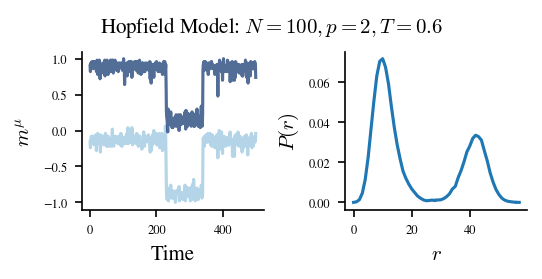

In [27]:
set_font_sizes('tight')
colors = plt.get_cmap('Blues')(np.linspace(0.4,1,p))
fig , axes = create_fig(1,2,sharex=False)

ax = axes[0]
for i in range(p):
    ax.plot(M[:,i],color=colors[i],alpha=0.7)

ax.set_xlabel(r'Time')
ax.set_ylabel(r'$m^{\mu}$')

ax = axes[1]
ax.plot(r,P)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$P(r)$')

fig.suptitle(rf'Hopfield Model: $N={N}, p={p}, T={T}$')

params = make_params_dict(['N','T','p'])
save_fig(fig,'pattern_jumps',params,date=False)